In [11]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

In [12]:
data = pd.read_csv("Mall_Customers.csv")
data.head()

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [13]:
X = data[['Annual Income (k$)','Spending Score (1-100)']]

In [15]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

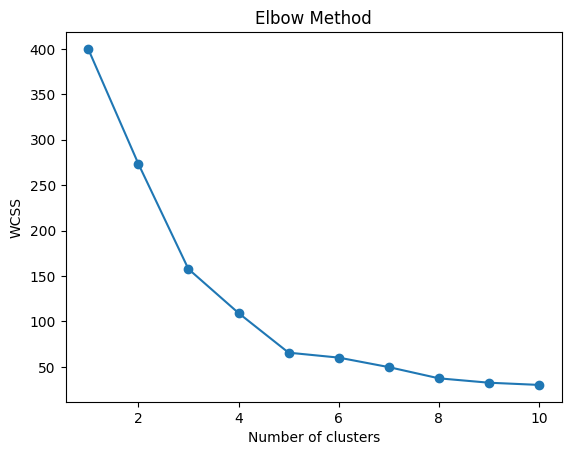

In [17]:
wcss = []

for k in range(1,11):
    kmeans = KMeans(n_clusters=k,random_state=42)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

plt.plot(range(1,11),wcss,marker='o')
plt.xlabel('Number of clusters')
plt.ylabel('WCSS')
plt.title('Elbow Method')
plt.show()

In [18]:
kmeans = KMeans(n_clusters=5,random_state=42)
data['Cluster']=kmeans.fit_predict(X_scaled)

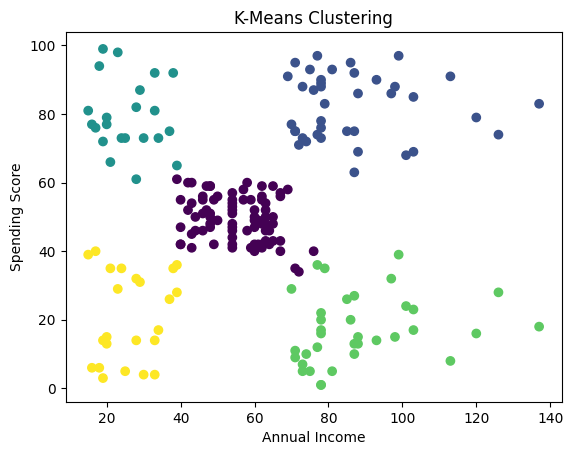

In [19]:
plt.scatter(
    X.iloc[:, 0],
    X.iloc[:, 1],
    c=data['Cluster']
)
plt.xlabel('Annual Income')
plt.ylabel('Spending Score')
plt.title('K-Means Clustering')
plt.show()